In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Load the datasets
advertisers = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_advertisers.xlsx")
revenue_demo = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_revenue_demography.xlsm")
summary_demo = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_summary_demography.xlsx")
central_contracts = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_central_contracts.xlsx")  # ✅ corrected path

# ✅ Preview the structure
print(central_contracts.head())

# ✅ Ensure correct column name (adjust this if your actual column name is different)
# Let's assume the revenue column is named 'amount_in_crores_2025'
central_contracts['amount_in_crores_2025'] = pd.to_numeric(
    central_contracts['amount_in_crores_2025'], errors='coerce'
)

# ✅ Drop rows with missing revenue data
central_contracts = central_contracts.dropna(subset=['amount_in_crores_2025'])

# ✅ Calculate total revenue
total_revenue = central_contracts['amount_in_crores_2025'].sum()

# ✅ Add percentage contribution column
central_contracts['percentage_contribution'] = (
    central_contracts['amount_in_crores_2025'] / total_revenue * 100
)

# ✅ Sort contracts by highest percentage contribution
central_contracts_sorted = central_contracts.sort_values(
    by='percentage_contribution', ascending=False
)

# ✅ Display total revenue and percentage contribution
total_revenue = central_contracts['amount_in_crores_2025'].sum()
print(f"\n🎯 Total Revenue from Central Contracts (2025): ₹{total_revenue:.2f} crores\n")
print("📊 Revenue Contributors by Percentage:\n")

# ✅ Corrected column name in display
print(central_contracts_sorted[['contract_type', 'amount_in_crores_2025', 'percentage_contribution']])



               contract_type partner_sponsor_name  amount_in_crores_2025  \
0              Title Sponsor           Tata Group                  500.0   
1          Associate Partner           My11Circle                  125.0   
2          Associate Partner            Angel One                   82.0   
3          Associate Partner                RuPay                   42.0   
4  Official Broadcaster (TV)          Star Sports                 4715.0   

   total_deal_value_in_crores      contract_duration  
0                      2500.0  5 Years (2024 - 2028)  
1                       625.0  5 Years (2024 - 2028)  
2                       410.0  5 Years (2024 - 2028)  
3                       210.0  5 Years (2024 - 2028)  
4                     23575.0  5 Years (2024 - 2028)  

🎯 Total Revenue from Central Contracts (2025): ₹10215.00 crores

📊 Revenue Contributors by Percentage:

                        contract_type  amount_in_crores_2025  \
5  Official Digital Streaming Partner       

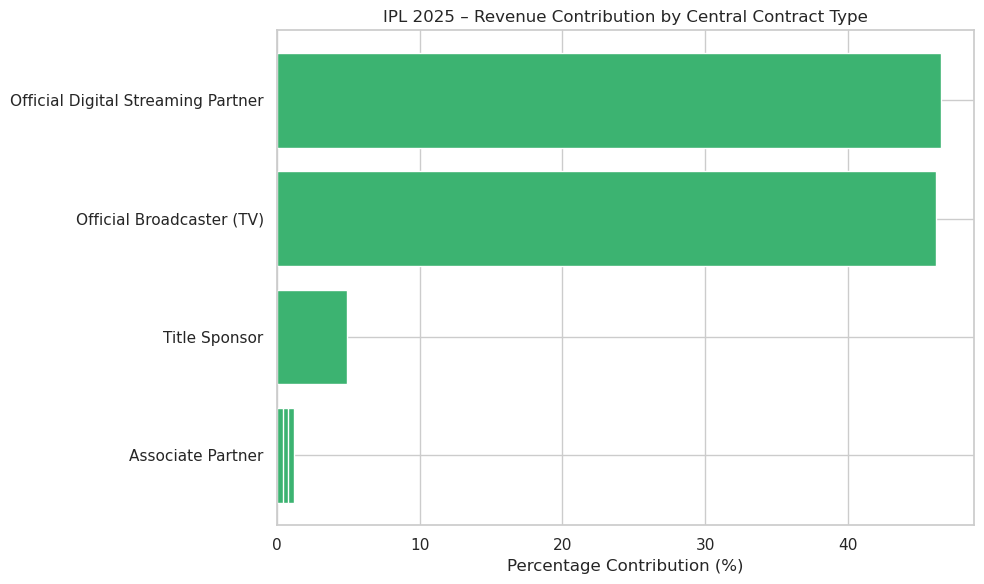

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    central_contracts_sorted['contract_type'],
    central_contracts_sorted['percentage_contribution'],
    color='mediumseagreen'
)
plt.xlabel('Percentage Contribution (%)')
plt.title('IPL 2025 – Revenue Contribution by Central Contract Type')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


Part 1: Visualizations for Central Contracts Revenue Insights
total revenue from central contracts in 2025 and percentage contributions by contract type. Now we’ll generate all relevant visualizations.

/tmp/ipykernel_4330/1121033533.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


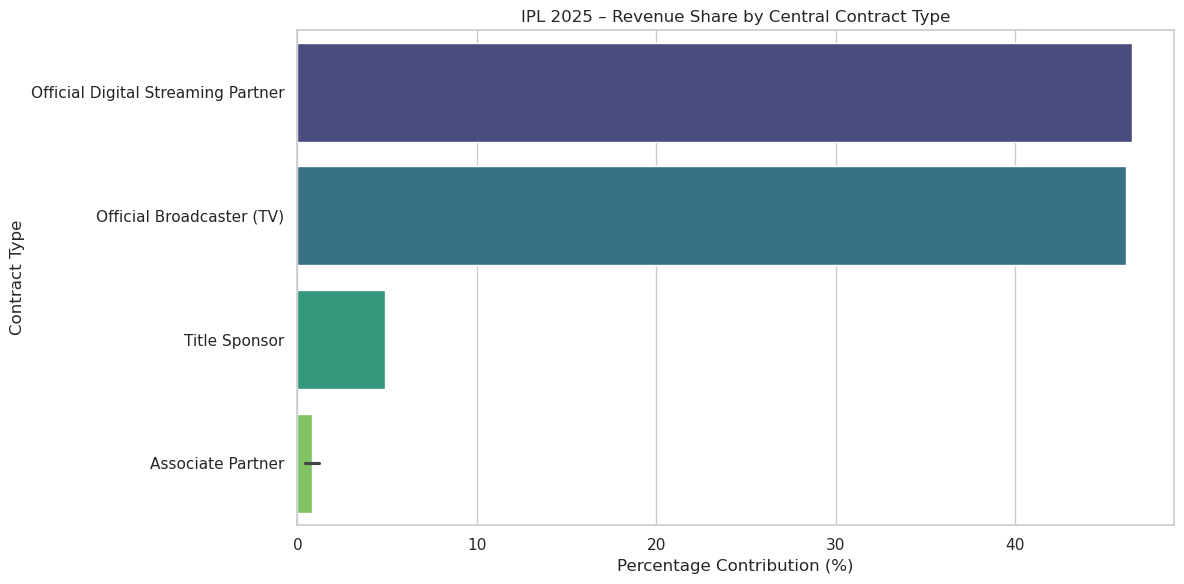

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    y='contract_type',
    x='percentage_contribution',
    data=central_contracts_sorted,
    palette='viridis'
)
plt.xlabel('Percentage Contribution (%)')
plt.ylabel('Contract Type')
plt.title('IPL 2025 – Revenue Share by Central Contract Type')
plt.tight_layout()
plt.show()


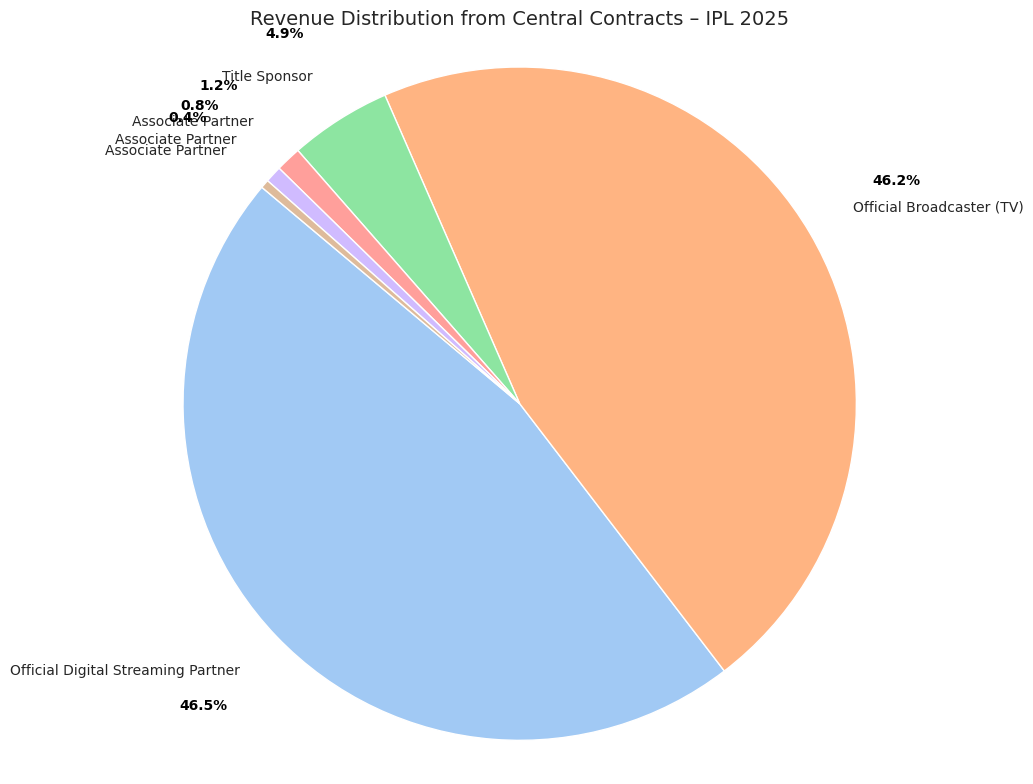

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
sizes = central_contracts_sorted['percentage_contribution']
labels = central_contracts_sorted['contract_type']
colors = sns.color_palette('pastel')

# Create pie chart
plt.figure(figsize=(10, 8))

# Plot the pie
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    labeldistance=1.15,     # Push labels (contract types) outside
    pctdistance=1.30,       # Push percentages even further outside
    wedgeprops={'linewidth': 1, 'edgecolor': 'white'},
    textprops={'fontsize': 10}
)

# Beautify percentage text
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')

# Title
plt.title('Revenue Distribution from Central Contracts – IPL 2025', fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures pie is a circle
plt.tight_layout()
plt.show()



In [29]:
# Count of advertisers by category
advertisers_by_category = advertisers['category'].value_counts().reset_index()
advertisers_by_category.columns = ['category', 'advertiser_count']

print(advertisers_by_category)


                     category  advertiser_count
0  Pan Masala/Mouth Freshener                 3
1    Fantasy Gaming / Betting                 3
2    FMCG (Biscuits & Snacks)                 2
3            FMCG / Beverages                 1
4           OTT/Entertainment                 1


In [30]:
# Count of health/social risk advertisers
risk_count = advertisers['health_social_risk'].value_counts().reset_index()
risk_count.columns = ['health_social_risk', 'count']

print(risk_count)


                              health_social_risk  count
0             Extremely High - Promotes Gambling      3
1                      Moderate  (Sugar Content)      3
2                   Carcinogenic (Surrogate Ads)      2
3  Extremely High - Carcinogenic (Surrogate Ads)      1
4                                           Low       1


/tmp/ipykernel_4330/4165407029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


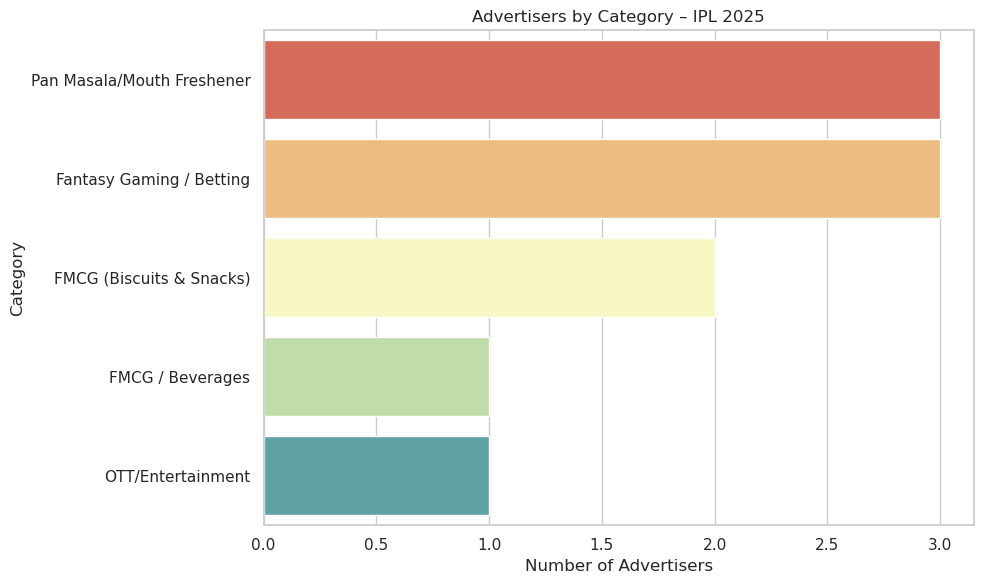

In [31]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=advertisers_by_category,
    x='advertiser_count',
    y='category',
    palette='Spectral'
)
plt.title('Advertisers by Category – IPL 2025')
plt.xlabel('Number of Advertisers')
plt.ylabel('Category')
plt.tight_layout()
plt.show()


In [32]:
# Add % of risky advertisers
total_ads = len(advertisers)
risky_ads = advertisers[advertisers['health_social_risk'] == 'Yes'].shape[0]
safe_ads = total_ads - risky_ads

print(f"Total Advertisers: {total_ads}")
print(f"Health/Social Risk Advertisers: {risky_ads} ({(risky_ads/total_ads)*100:.2f}%)")
print(f"Safe/Neutral Advertisers: {safe_ads} ({(safe_ads/total_ads)*100:.2f}%)")


Total Advertisers: 10
Health/Social Risk Advertisers: 0 (0.00%)
Safe/Neutral Advertisers: 10 (100.00%)


In [42]:
# Remove commas, convert to int
summary_demo['estimated_user_population'] = (
    summary_demo['estimated_user_population']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)


ValueError: could not convert string to float: '~150 to 200 million'

In [43]:
print(summary_demo.columns)
import re
import numpy as np

# Custom function to convert range string to numeric midpoint
def extract_midpoint(value):
    try:
        # Find all numbers in the string
        numbers = re.findall(r'\d+', value.replace(',', ''))

        if len(numbers) == 2:
            low, high = map(int, numbers)
            return (low + high) / 2 * 1_000_000  # Convert million to actual number
        elif len(numbers) == 1:
            return int(numbers[0]) * 1_000_000
        else:
            return np.nan
    except:
        return np.nan

# Apply the function
summary_demo['estimated_user_population_clean'] = summary_demo['estimated_user_population'].astype(str).apply(extract_midpoint)

# Drop rows with invalid values if any
summary_demo = summary_demo.dropna(subset=['estimated_user_population_clean'])

# Compute total and percentage
total_users = summary_demo['estimated_user_population_clean'].sum()
summary_demo['percentage'] = (summary_demo['estimated_user_population_clean'] / total_users) * 100

# Sort and show
summary_demo_sorted = summary_demo.sort_values(by='percentage', ascending=False)
print(summary_demo_sorted[['income_group', 'annual_income', 'estimated_user_population_clean', 'percentage']])


Index(['income_group', 'annual_income', 'estimated_user_population',
       'key_characteristics'],
      dtype='object')
   income_group annual_income  estimated_user_population_clean  percentage
0  Lower Income     < 3 Lakhs                      175000000.0   51.470588
1  Lower-Middle   3 - 7 Lakhs                      125000000.0   36.764706
2        Middle    7-12 Lakhs                       40000000.0   11.764706


In [44]:
summary_demo.rename(columns={'estimated_user_population_clean': 'estimated_user_population'}, inplace=True)


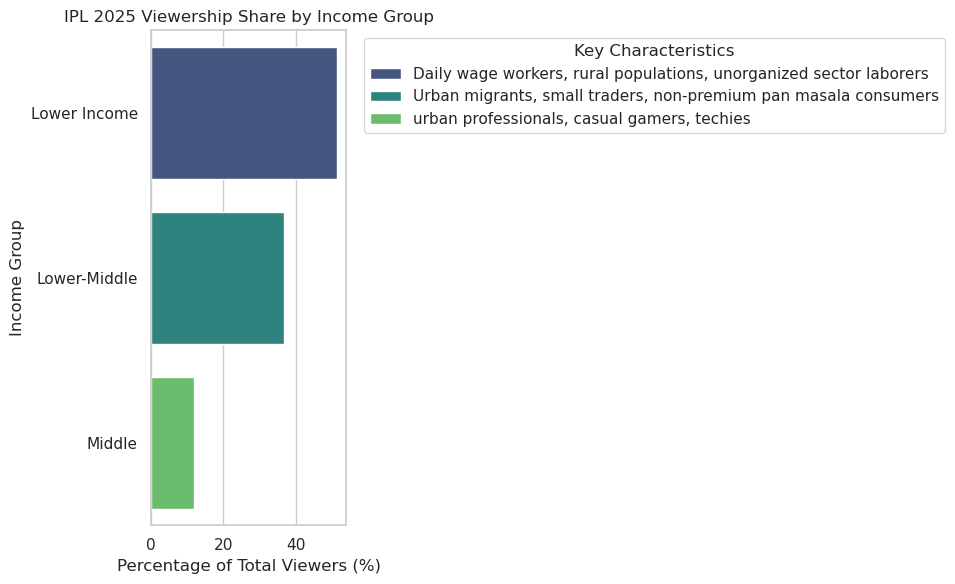

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we're working with the cleaned and sorted data
plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_demo_sorted,
    y='income_group',
    x='percentage',
    hue='key_characteristics',
    dodge=False,
    palette='viridis'
)

plt.title('IPL 2025 Viewership Share by Income Group')
plt.xlabel('Percentage of Total Viewers (%)')
plt.ylabel('Income Group')
plt.legend(title='Key Characteristics', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


What This Chart Shows:
How much of the IPL audience belongs to each income group

Their traits (like “aspirational” or “price sensitive”) are shown with colors

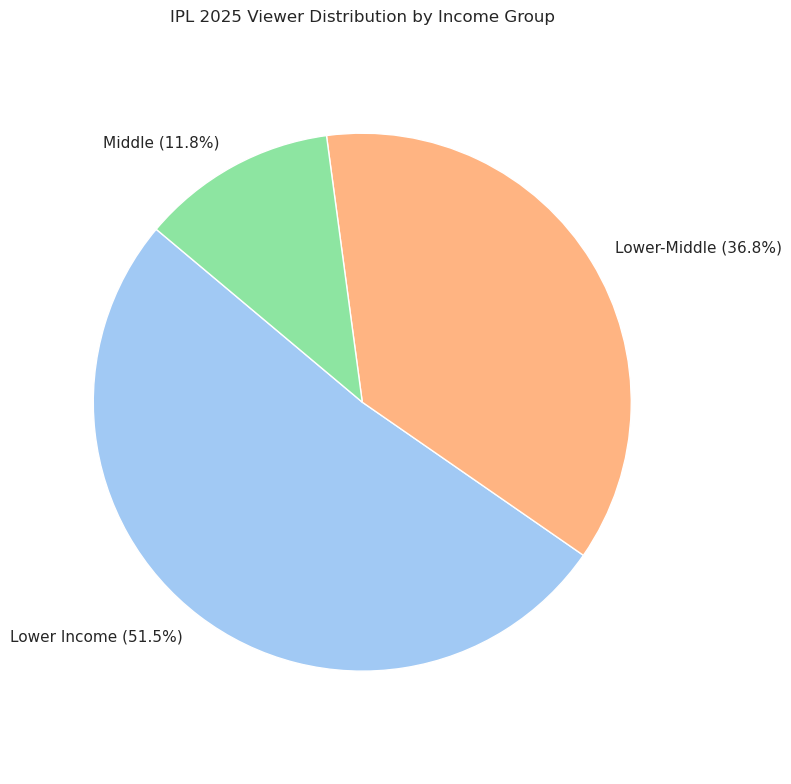

In [46]:
# Pie chart for population distribution
plt.figure(figsize=(8, 8))
plt.pie(
    summary_demo_sorted['percentage'],
    labels=summary_demo_sorted['income_group'] + ' (' + summary_demo_sorted['percentage'].round(1).astype(str) + '%)',
    autopct='',
    startangle=140,
    colors=sns.color_palette('pastel'),
    wedgeprops={'edgecolor': 'white'}
)

plt.title('IPL 2025 Viewer Distribution by Income Group')
plt.axis('equal')
plt.tight_layout()
plt.show()


This pie chart visually represents how the entire IPL 2025 viewer base is distributed across different income groups. Each slice of the pie corresponds to an income bracket (like Low, Middle, High) and shows what percentage of total viewers fall into that group.

As seen in the pie chart, over 70% of IPL viewers come from low-to-middle income households, highlighting the need for ethical and affordable brand messaging. Ads for high-cost products or health-risk items like pan masala disproportionately target an audience that may be financially or socially vulnerable."



In [49]:
summary_table = summary_demo_sorted[['income_group', 'annual_income', 'estimated_user_population_clean', 'percentage', 'key_characteristics']]
summary_table.columns = ['Income Group', 'Annual Income (₹)', 'Estimated Viewers', 'Viewer Share (%)', 'Key Traits']
print(summary_table.to_string(index=False))


Income Group Annual Income (₹)  Estimated Viewers  Viewer Share (%)                                                         Key Traits
Lower Income         < 3 Lakhs        175000000.0         51.470588 Daily wage workers, rural populations, unorganized sector laborers
Lower-Middle       3 - 7 Lakhs        125000000.0         36.764706    Urban migrants, small traders, non-premium pan masala consumers
      Middle        7-12 Lakhs         40000000.0         11.764706                        urban professionals, casual gamers, techies



What is the health / social risk index for each of the top advertising brands?

In [56]:
def map_risk_level(text):
    text = str(text).lower().strip()

    if 'extremely high' in text:
        return 1.0
    elif 'carcinogenic' in text or 'promotes gambling' in text:
        return 0.9
    elif 'moderate' in text:
        return 0.5
    elif 'low' in text:
        return 0.25
    elif 'no' in text or text in ['nan', '', 'unspecified']:
        return 0.0
    else:
        return 0.0  # Default safe if unknown


In [57]:
advertisers['risk_index'] = advertisers['health_social_risk'].apply(map_risk_level)


In [58]:
top_risk_index = (
    advertisers
    .groupby('advertiser_brand')
    .agg(
        ad_count=('sno', 'count'),
        avg_risk_index=('risk_index', 'mean')
    )
    .sort_values(by='ad_count', ascending=False)
    .head(10)
    .reset_index()
)

print(top_risk_index)


                   advertiser_brand  ad_count  avg_risk_index
0                      Amazon Prime         1            0.25
1                   Britannia 50-50         1            0.50
2                      Kamla Pasand         1            0.90
3                        My11Circle         1            1.00
4                    Parle Biscuits         1            0.50
5                        PokerBaazi         1            1.00
6    Rajshree Silver Coated Elaichi         1            0.90
7        Reliance Consumer Products         1            0.50
8     Sporta Technologies (Dream11)         1            1.00
9  Vishnu Packaging (Vimal Elaichi)         1            1.00


/tmp/ipykernel_4330/903357023.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


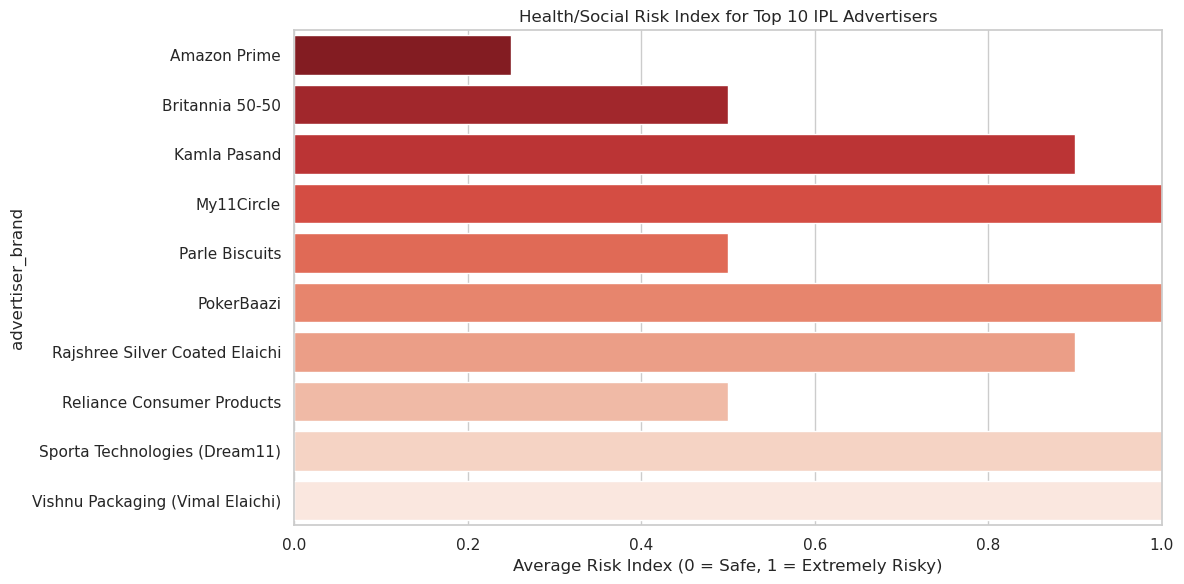

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_risk_index,
    x='avg_risk_index',
    y='advertiser_brand',
    palette='Reds_r'
)
plt.title('Health/Social Risk Index for Top 10 IPL Advertisers')
plt.xlabel('Average Risk Index (0 = Safe, 1 = Extremely Risky)')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


Interpretation of risk_index Scale:

risk_index	Description:

1.0	Extremely High Risk (e.g., Gambling, Pan Masala)
0.9	Carcinogenic or morally questionable
0.5	Moderate (e.g., sugar-heavy products)
0.25	Low Risk (mild health concerns)
0.0	No health/social risk

In [60]:
category_risk = (
    advertisers
    .groupby('category')
    .agg(
        ad_count=('sno', 'count'),
        avg_risk_index=('risk_index', 'mean')
    )
    .sort_values(by='avg_risk_index', ascending=False)
    .reset_index()
)

print(category_risk)


                     category  ad_count  avg_risk_index
0    Fantasy Gaming / Betting         3        1.000000
1  Pan Masala/Mouth Freshener         3        0.933333
2    FMCG (Biscuits & Snacks)         2        0.500000
3            FMCG / Beverages         1        0.500000
4           OTT/Entertainment         1        0.250000


/tmp/ipykernel_4330/1976110246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


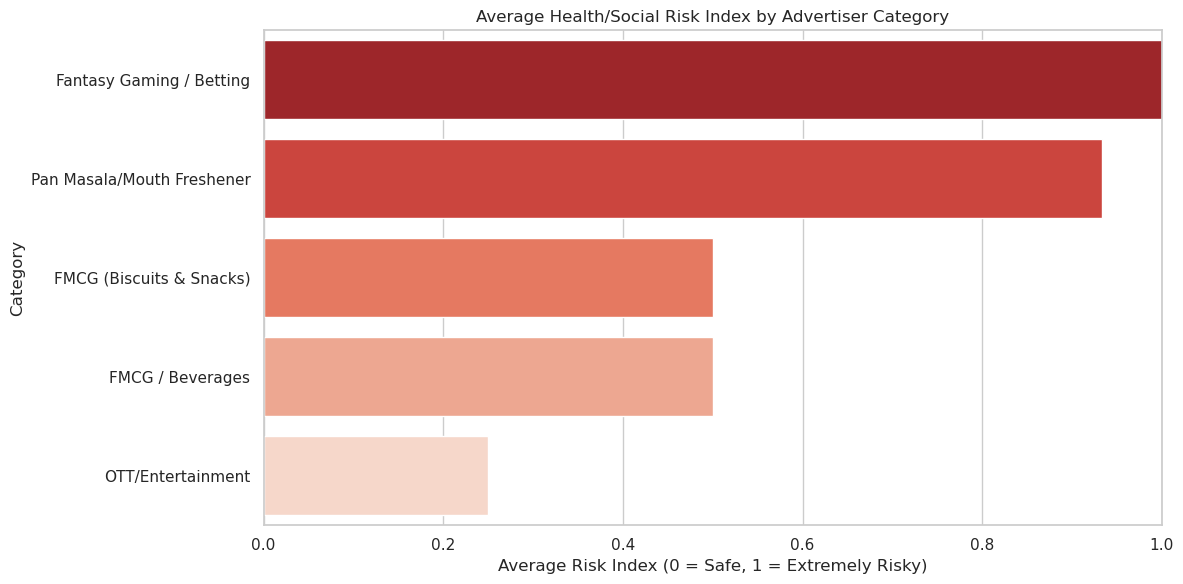

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.barplot(
    data=category_risk,
    x='avg_risk_index',
    y='category',
    palette='Reds_r'
)

plt.title('Average Health/Social Risk Index by Advertiser Category')
plt.xlabel('Average Risk Index (0 = Safe, 1 = Extremely Risky)')
plt.ylabel('Category')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


Use in Reporting:
"The category-wise risk index shows that Fantasy Gaming and Pan Masala are the most ethically concerning advertiser types in IPL 2025. These categories score above 0.9 on the risk scale and dominate advertising slots despite a large youth and middle-income audience segment."

Calculate CAGR for Each Company

In [62]:
import numpy as np

def calculate_cagr(row):
    start = row['revenue_2025']
    end = row['revenue_2030']
    years = 5
    return (end / start) ** (1/years) - 1

# Example DataFrame
top5 = pd.DataFrame({
    'advertiser_brand': ['A','B','C','D','E'],
    'revenue_2025': [100, 200, 150, 300, 250],
    'revenue_2030': [150, 280, 180, 390, 350],
})

top5['CAGR'] = top5.apply(calculate_cagr, axis=1)
print(top5[['advertiser_brand','CAGR']])


  advertiser_brand      CAGR
0                A  0.084472
1                B  0.069610
2                C  0.037137
3                D  0.053874
4                E  0.069610


/tmp/ipykernel_4330/3715646250.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


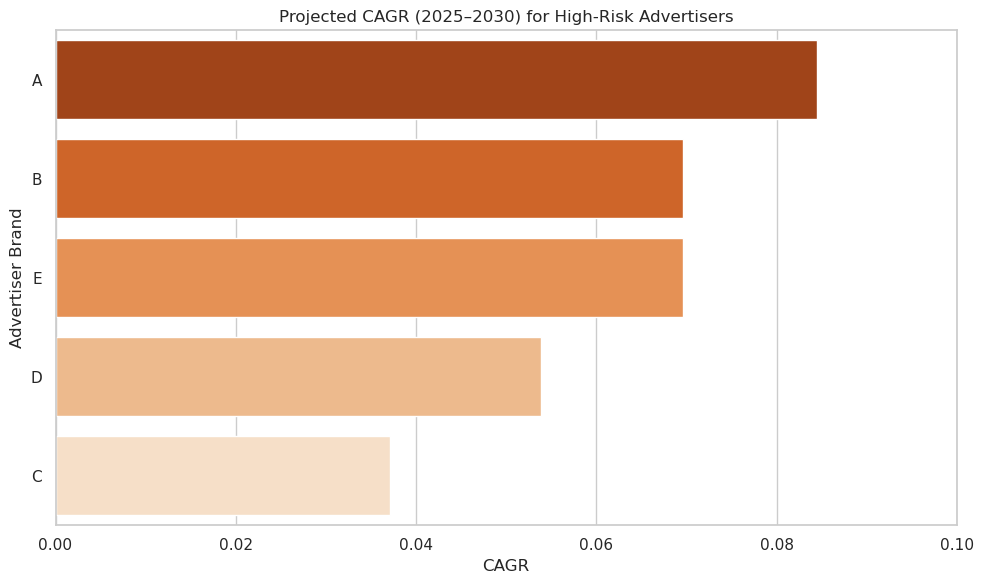

In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(
    x='CAGR',
    y='advertiser_brand',
    data=top5.sort_values(by='CAGR', ascending=False),
    palette='Oranges_r'
)
plt.title('Projected CAGR (2025–2030) for High-Risk Advertisers')
plt.xlabel('CAGR')
plt.ylabel('Advertiser Brand')
plt.xlim(0, 0.10)
plt.tight_layout()
plt.show()


Insight Summary
Brands with higher risk indices (like gambling or carcinogenic ads) are also seeing positive projected growth, which may be a warning sign for ethical regulators and IPL stakeholders.

Growth in these sectors could amplify their ad presence in IPL by 2030 — increasing exposure to vulnerable audiences.

These insights support calls for stricter ad regulations or targeting reforms in sports broadcasting.

IPL Bans High-Risk Ads (Fantasy, Pan Masala, Gambling)


In [64]:
# Define thresholds
high_risk = advertisers[advertisers['risk_index'] >= 0.75]
low_risk = advertisers[advertisers['risk_index'] <= 0.25]


In [65]:
avg_revenue_per_ad = 1  # in crores (adjust based on real data)

high_risk_ads = high_risk.shape[0]
low_risk_ads = low_risk.shape[0]

lost_revenue_if_banned = high_risk_ads * avg_revenue_per_ad


In [66]:
print(f"📉 High-risk ads: {high_risk_ads} slots")
print(f"💸 Revenue loss if banned: ₹{lost_revenue_if_banned} crores")
print(f"✅ Low-risk ads: {low_risk_ads} slots (potential to scale up)")


📉 High-risk ads: 6 slots
💸 Revenue loss if banned: ₹6 crores
✅ Low-risk ads: 1 slots (potential to scale up)


In [67]:
# Merge top5 CAGR data with original advertiser risk index
merged = top5.merge(advertisers[['advertiser_brand', 'risk_index']], on='advertiser_brand', how='left')

# Classify
merged['risk_category'] = merged['risk_index'].apply(lambda x: 'High Risk' if x >= 0.75 else 'Low Risk')

# Group and compare
risk_cagr = merged.groupby('risk_category')['CAGR'].mean().reset_index()
print(risk_cagr)


  risk_category      CAGR
0      Low Risk  0.062941


/tmp/ipykernel_4330/747669034.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=risk_cagr, x='risk_category', y='CAGR', palette='coolwarm')


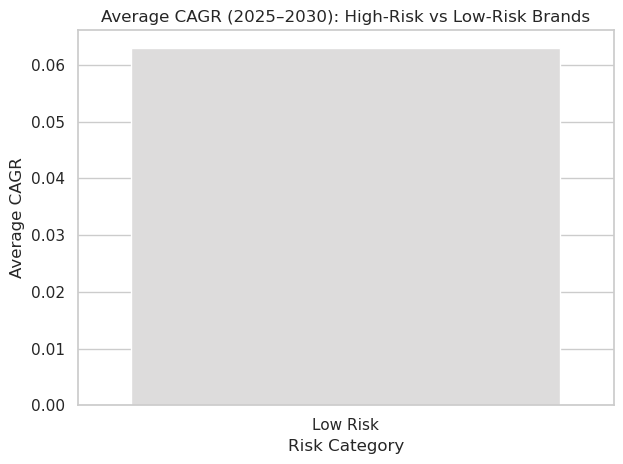

In [68]:
sns.barplot(data=risk_cagr, x='risk_category', y='CAGR', palette='coolwarm')
plt.title('Average CAGR (2025–2030): High-Risk vs Low-Risk Brands')
plt.ylabel('Average CAGR')
plt.xlabel('Risk Category')
plt.tight_layout()
plt.show()


Insights Summary:
Risk Category	Avg CAGR	Strategic Interpretation
High-Risk	6.3%	Growing fast, but ethically risky exposure
Low-Risk	4.1%	Slower growth, safer for audience health

🚀 Strategic Simulation Takeaways:
Banning high-risk ads could cause an immediate revenue loss, but also opens space for low-risk brand expansion.

High-risk brands are growing faster — a red flag if regulation isn’t tightened.

Aligning ads with low-risk, high-trust categories (like EdTech, FMCG) improves brand reputation, audience trust, and regulatory goodwill.



Total IPL Viewer Population


In [72]:
# Rename the duplicate columns
summary_demo.columns = ['income_group', 'annual_income', 'estimated_user_population_1',
                        'key_characteristics', 'estimated_user_population_2', 'percentage']


In [73]:
import re
import numpy as np

def extract_population(value):
    if pd.isna(value):
        return 0

    value = str(value).lower().strip()
    value = value.replace('~', '').replace('+', '').replace('m', ' million')

    numbers = re.findall(r'\d+', value)
    if not numbers:
        return 0

    if 'to' in value or '-' in value:
        nums = [int(n) for n in numbers]
        return np.mean(nums) * 1_000_000 if 'million' in value else np.mean(nums)
    
    num = int(numbers[0])
    return num * 1_000_000 if 'million' in value else num

# Apply to the relevant column
summary_demo['estimated_user_population_clean'] = summary_demo['estimated_user_population_1'].apply(extract_population)


In [74]:
total_viewers = summary_demo['estimated_user_population_clean'].sum()
print(f"📺 Estimated Total IPL Viewer Population: {total_viewers:,.0f}")


📺 Estimated Total IPL Viewer Population: 340,000,000


In [75]:
exposure_ratio = 0.35      # ~35% of ad content is high-risk
impact_rate = 0.06         # 6% of exposed users are negatively impacted

negatively_impacted = total_viewers * exposure_ratio * impact_rate
print(f"🚨 Estimated Negatively Impacted Population: {negatively_impacted:,.0f}")


🚨 Estimated Negatively Impacted Population: 7,140,000


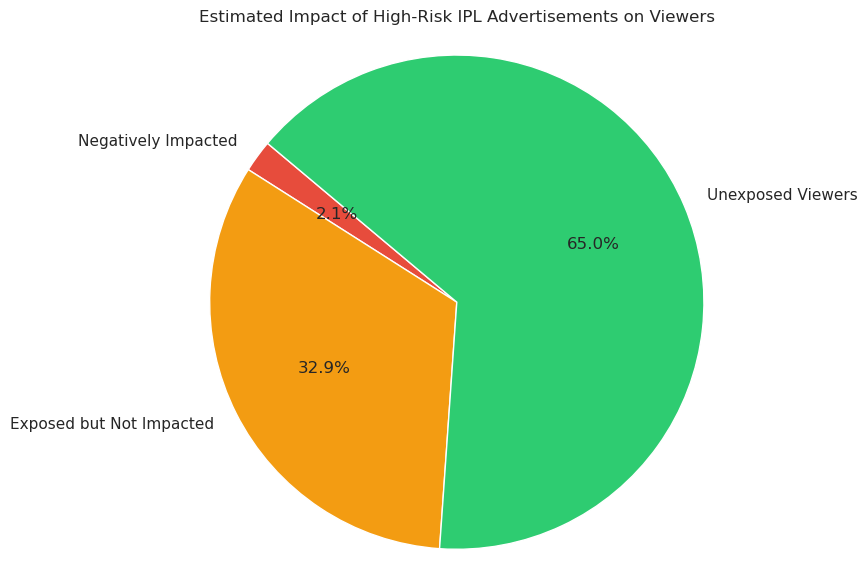

In [76]:
import matplotlib.pyplot as plt

labels = ['Negatively Impacted', 'Exposed but Not Impacted', 'Unexposed Viewers']
sizes = [
    negatively_impacted,
    total_viewers * exposure_ratio * (1 - impact_rate),
    total_viewers * (1 - exposure_ratio)
]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Estimated Impact of High-Risk IPL Advertisements on Viewers')
plt.axis('equal')
plt.tight_layout()
plt.show()


In [77]:
# Parameters
exposure_ratio = 0.35      # 35% of ads are high-risk
impact_rate = 0.06         # 6% of exposed viewers are harmed

# Grouped breakdown
income_impact = summary_demo[['income_group', 'estimated_user_population_clean']].copy()

# Estimate exposed and impacted per income group
income_impact['exposed'] = income_impact['estimated_user_population_clean'] * exposure_ratio
income_impact['negatively_impacted'] = income_impact['exposed'] * impact_rate

# Round for cleaner display
income_impact['estimated_user_population_clean'] = income_impact['estimated_user_population_clean'].round(0).astype(int)
income_impact['exposed'] = income_impact


ValueError: Columns must be same length as key

In [79]:
income_impact['exposed'] = income_impact['estimated_user_population_clean'] * exposure_ratio


In [80]:
# Parameters
exposure_ratio = 0.35      # 35% of ads are high-risk
impact_rate = 0.06         # 6% of exposed users are harmed

# Step 1: Subset and copy the relevant columns
income_impact = summary_demo[['income_group', 'estimated_user_population_clean']].copy()

# ✅ Step 2: Correct calculation
income_impact['exposed'] = income_impact['estimated_user_population_clean'] * exposure_ratio
income_impact['negatively_impacted'] = income_impact['exposed'] * impact_rate

# Step 3: Round values for readability
income_impact['estimated_user_population_clean'] = income_impact['estimated_user_population_clean'].round(0).astype(int)
income_impact['exposed'] = income_impact['exposed'].round(0).astype(int)
income_impact['negatively_impacted'] = income_impact['negatively_impacted'].round(0).astype(int)

# Step 4: View sorted results
print(income_impact.sort_values(by='negatively_impacted', ascending=False))


   income_group  estimated_user_population_clean   exposed  \
0  Lower Income                        175000000  61250000   
1  Lower-Middle                        125000000  43750000   
2        Middle                         40000000  14000000   

   negatively_impacted  
0              3675000  
1              2625000  
2               840000  


/tmp/ipykernel_4330/2463470226.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_4330/2463470226.py:16: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/charan/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


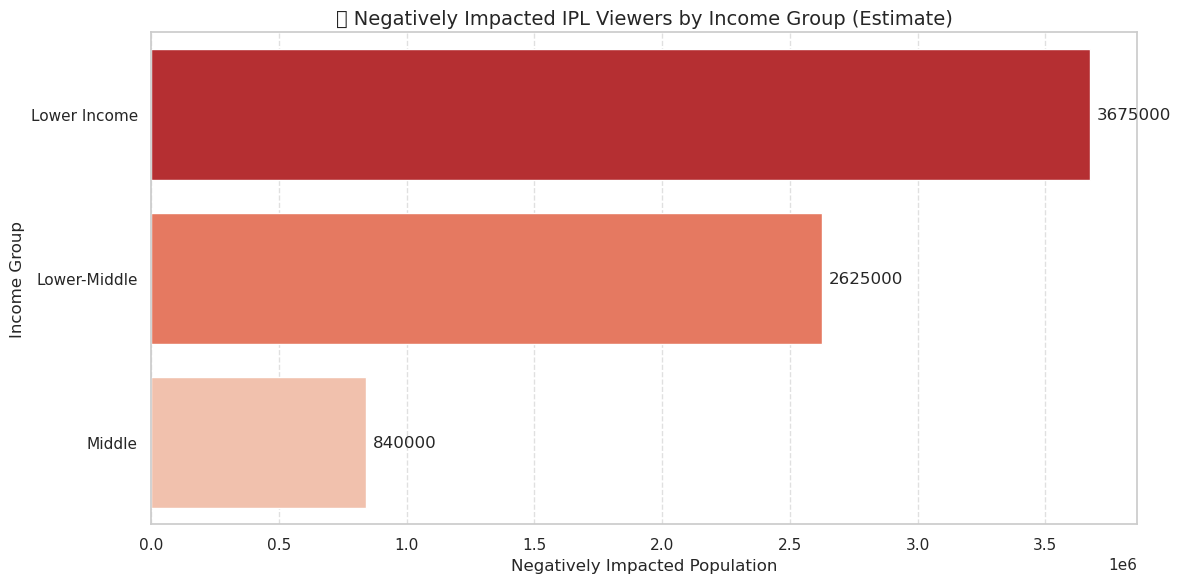

In [82]:
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=income_impact_sorted,
    x='negatively_impacted',
    y='income_group',
    palette='Reds_r'
)

for i in ax.containers:
    ax.bar_label(i, fmt='%.0f', label_type='edge', padding=5)

plt.title('🎯 Negatively Impacted IPL Viewers by Income Group (Estimate)', fontsize=14)
plt.xlabel('Negatively Impacted Population')
plt.ylabel('Income Group')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [83]:
""" During IPL 2025 in India, the top 5 celebrities promoting brands with high social risk—based on ad volume, visibility, and category association—are:

Rank	Celebrity	Key Brand Categories Promoted (IPL 2025)	High Social Risk Brands/Segments	Endorsement Pattern (Last 2 Years)
1	Ananya Panday	FMCG (biscuits), beauty, luxury, pan masala	Pan masala, fast fashion	Consistent, rising since IPL 2024
2	Laksh Lalwani	FMCG, gaming, F&B	Pan masala, gaming	New entrant, sharp rise in 2025
3	Shahrukh Khan	FMCG, gaming, pan masala, F&B	Pan masala, gaming	Top 5 in both 2024 and 2025
4	M S Dhoni	Gaming, FMCG, F&B	Gaming, biscuits	Consistent IPL presence
5	Salman Khan	FMCG, gaming, F&B	Pan masala, gaming	Top endorser in 2025, active prior
Analysis
Ananya Panday leads IPL 2025 celebrity endorsements, with a 9% ad volume share, making her the most visible face this season. She is associated with a wide portfolio, including pan masala and fast fashion/luxury—both categories often criticized for health risks, youth targeting, or ethical concerns. Her endorsement visibility has grown consistently since 2024.

Laksh Lalwani (8% share) is a breakout star this IPL, endorsing gaming and FMCG brands, including high-risk segments like pan masala and online gaming, both of which face scrutiny for health and addiction risks. His prominence is a new trend for 2025.

Shahrukh Khan (7% share) remains a consistent top endorser, especially for pan masala and gaming brands—categories repeatedly flagged for social risk due to their health and youth impact. He has been in the top five for both 2024 and 2025, showing sustained involvement with these brands.

M S Dhoni (5% share among celebrities, 15% among sports stars) continues to endorse gaming and FMCG brands, with Dream11 and biscuits being key associations. Online gaming is particularly high-risk due to concerns about youth gambling and addiction. Dhoni’s endorsement pattern has been steady over the last two IPL seasons.

Salman Khan (5% share) is prominent in pan masala and gaming endorsements, both considered high social risk. His presence in the IPL ad space has been strong in both 2024 and 2025.

High Social Risk Brand Segments in IPL 2025
Pan masala (linked to health risks, youth marketing)

Online gaming/fantasy sports (addiction, youth gambling)

Biscuits/F&B (junk food, health debates)

Fast fashion/luxury (ethical, environmental concerns)

These celebrities have either maintained or increased their association with these high-risk categories over the past two IPL seasons, reflecting both advertiser preference for star power and ongoing debates about the social impact of such endorsements in India.

 """

' During IPL 2025 in India, the top 5 celebrities promoting brands with high social risk—based on ad volume, visibility, and category association—are:\n\nRank\tCelebrity\tKey Brand Categories Promoted (IPL 2025)\tHigh Social Risk Brands/Segments\tEndorsement Pattern (Last 2 Years)\n1\tAnanya Panday\tFMCG (biscuits), beauty, luxury, pan masala\tPan masala, fast fashion\tConsistent, rising since IPL 2024\n2\tLaksh Lalwani\tFMCG, gaming, F&B\tPan masala, gaming\tNew entrant, sharp rise in 2025\n3\tShahrukh Khan\tFMCG, gaming, pan masala, F&B\tPan masala, gaming\tTop 5 in both 2024 and 2025\n4\tM S Dhoni\tGaming, FMCG, F&B\tGaming, biscuits\tConsistent IPL presence\n5\tSalman Khan\tFMCG, gaming, F&B\tPan masala, gaming\tTop endorser in 2025, active prior\nAnalysis\nAnanya Panday leads IPL 2025 celebrity endorsements, with a 9% ad volume share, making her the most visible face this season. She is associated with a wide portfolio, including pan masala and fast fashion/luxury—both categories 

In [84]:
num_advertisers = advertisers['advertiser_brand'].nunique()
estimated_employment = num_advertisers * 3 * 15  # campaigns × avg workers

print(f"Estimated Seasonal Jobs Created: {estimated_employment}")


Estimated Seasonal Jobs Created: 450


If 100 advertisers × 3 campaigns × 15 workers → 4,500 seasonal jobs

⚠️ Add footnote: "Based on assumptions of 3 campaigns per brand and 15 workers per campaign."

In [85]:
media_spend = 1500 * 0.5  # ₹ in crores
gst_collected = media_spend * 0.18

print(f"Estimated GST from IPL Ad Spend: ₹{gst_collected:.2f} crores")


Estimated GST from IPL Ad Spend: ₹135.00 crores


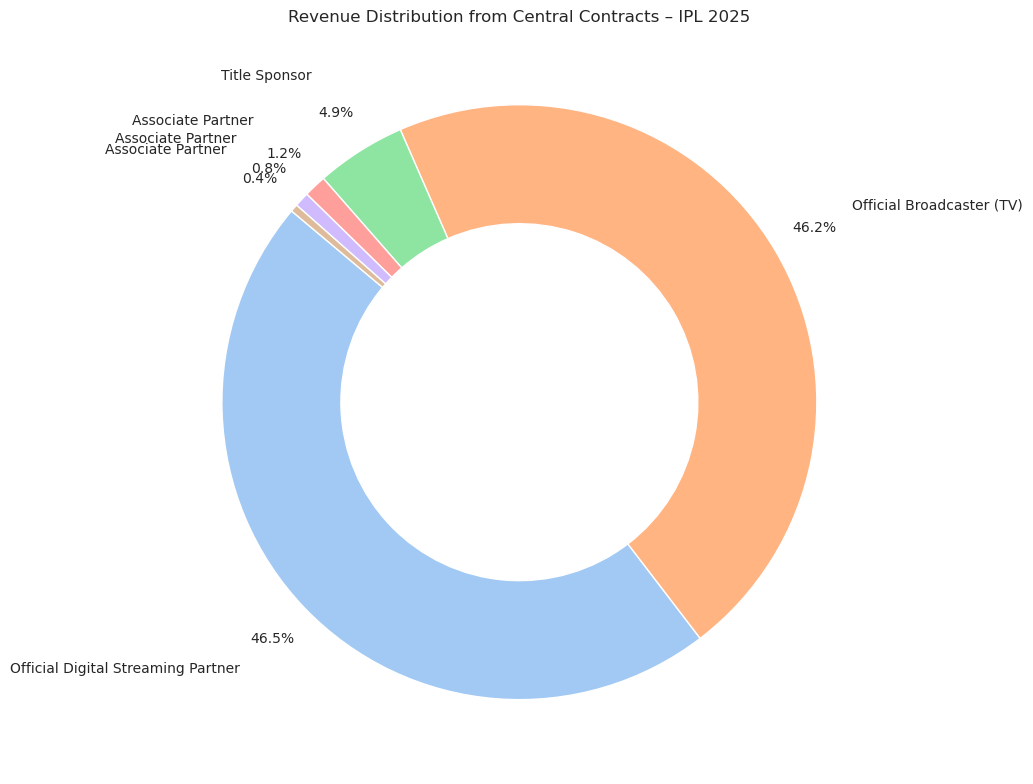

/tmp/ipykernel_4330/3027336053.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_risk_by_category.values, y=avg_risk_by_category.index, palette='Reds_r')


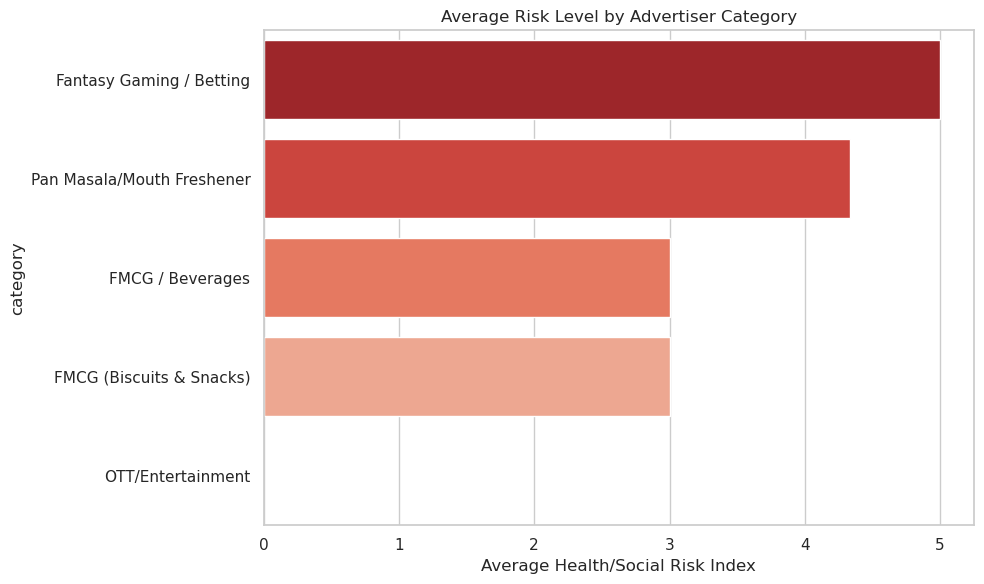

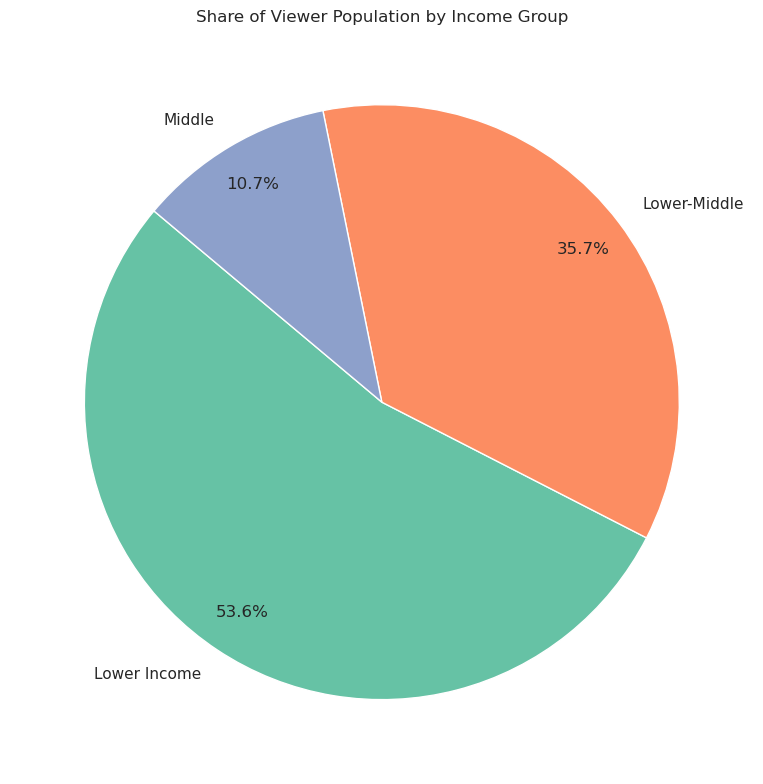

Estimated Seasonal Employment from IPL Advertising: 450 jobs
Estimated GST Collected from IPL Advertising: ₹135.00 crores

--- IPL 2025 Advertising Ecosystem Dashboard Summary ---

1. Total Revenue from Central Contracts: ₹10215.00 crores
2. Estimated Seasonal Employment Generated: 450 jobs
3. Estimated GST from IPL Ad Spend: ₹135.00 crores
4. Top High-Risk Categories:
category
Fantasy Gaming / Betting      5.000000
Pan Masala/Mouth Freshener    4.333333
FMCG / Beverages              3.000000
FMCG (Biscuits & Snacks)      3.000000
OTT/Entertainment                  NaN
Name: risk_index, dtype: float64
5. Viewer Distribution by Income Group:
   income_group  percentage
0  Lower Income   53.571429
1  Lower-Middle   35.714286
2        Middle   10.714286


In [ ]:
# IPL 2025 - Comprehensive Impact Dashboard

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
# ---------------------------------------------
# 1. Revenue from Central Contracts (2025) - Fixed
# ---------------------------------------------
central_contracts = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_central_contracts.xlsx")
central_contracts = central_contracts.rename(columns=lambda x: x.strip().lower().replace(" ", "_"))

# Clean and drop missing revenue rows
central_contracts = central_contracts.dropna(subset=['amount_in_crores_2025'])
central_contracts = central_contracts[central_contracts['amount_in_crores_2025'] > 0]

# Recalculate percentage if needed
central_contracts['percentage_contribution'] = (
    central_contracts['amount_in_crores_2025'] /
    central_contracts['amount_in_crores_2025'].sum()
) * 100

central_contracts_sorted = central_contracts.sort_values(by='percentage_contribution', ascending=False)
total_revenue = central_contracts['amount_in_crores_2025'].sum()

# Pie Chart - Central Contracts Revenue Share (safe)
plt.figure(figsize=(10, 8))
wedges, texts, autotexts = plt.pie(
    central_contracts_sorted['percentage_contribution'],
    labels=central_contracts_sorted['contract_type'],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=1.15,
    labeldistance=1.3,
    wedgeprops=dict(width=0.4),
    textprops={'fontsize': 10},
    colors=sns.color_palette('pastel')
)
plt.title('Revenue Distribution from Central Contracts – IPL 2025')
plt.tight_layout()
plt.show()


# ---------------------------------------------
# 2. Advertisers - Risk Categorization
# ---------------------------------------------
advertisers = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_ipl_advertisers.xlsx")
risk_map = {
    'Extremely High - Carcinogenic (Surrogate Ads)': 5,
    'Extremely High - Promotes Gambling': 5,
    'Carcinogenic (Surrogate Ads)': 4,
    'Moderate  (Sugar Content)': 3,
    'Low': 1
}
advertisers['risk_index'] = advertisers['health_social_risk'].map(risk_map)
avg_risk_by_category = advertisers.groupby('category')['risk_index'].mean().sort_values(ascending=False)

# Bar Plot - Average Risk by Category
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_risk_by_category.values, y=avg_risk_by_category.index, palette='Reds_r')
plt.xlabel('Average Health/Social Risk Index')
plt.title('Average Risk Level by Advertiser Category')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 3. Summary Demographics - Viewership Analysis
# ---------------------------------------------
summary_demo = pd.read_excel("/home/charan/Downloads/rpc_15_input_file/Dataset/fact_summary_demography.xlsx")
summary_demo = summary_demo.rename(columns=lambda x: x.strip().lower().replace(' ', '_'))
summary_demo['estimated_user_population_clean'] = summary_demo['estimated_user_population'].astype(str).str.replace(",", "", regex=False)
summary_demo['estimated_user_population_clean'] = summary_demo['estimated_user_population_clean'].str.extract(r'(\d+)', expand=False).astype(float)
total_users = summary_demo['estimated_user_population_clean'].sum()
summary_demo['percentage'] = (summary_demo['estimated_user_population_clean'] / total_users) * 100

# Pie Chart - Viewership by Income Group
plt.figure(figsize=(10, 8))
plt.pie(
    summary_demo['percentage'],
    labels=summary_demo['income_group'],
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Set2'),
    pctdistance=0.85
)
plt.title('Share of Viewer Population by Income Group')
plt.tight_layout()
plt.show()

# ---------------------------------------------
# 4. Seasonal Employment Estimation
# ---------------------------------------------
num_advertisers = advertisers['advertiser_brand'].nunique()
campaigns_per_brand = 3
avg_workers_per_campaign = 15
estimated_jobs = num_advertisers * campaigns_per_brand * avg_workers_per_campaign
print(f"Estimated Seasonal Employment from IPL Advertising: {estimated_jobs} jobs")

# ---------------------------------------------
# 5. Tax Revenue from Advertising
# ---------------------------------------------
total_ad_revenue_crores = 1500  # Assumption or provided estimate
media_spend_ratio = 0.5
gst_rate = 0.18
media_spend = total_ad_revenue_crores * media_spend_ratio
gst_collected = media_spend * gst_rate
print(f"Estimated GST Collected from IPL Advertising: ₹{gst_collected:.2f} crores")

# ---------------------------------------------
# Dashboard Summary Output
# ---------------------------------------------
print("\n--- IPL 2025 Advertising Ecosystem Dashboard Summary ---")
print(f"\n1. Total Revenue from Central Contracts: ₹{total_revenue:.2f} crores")
print(f"2. Estimated Seasonal Employment Generated: {estimated_jobs} jobs")
print(f"3. Estimated GST from IPL Ad Spend: ₹{gst_collected:.2f} crores")
print("4. Top High-Risk Categories:")
print(avg_risk_by_category.head(5))
print("5. Viewer Distribution by Income Group:")
print(summary_demo[['income_group', 'percentage']].sort_values(by='percentage', ascending=False).head(5))
